# **Zomato Restaurant Data Analysis**

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## **Step 1:LOAD & INSPECT DATA**

In [29]:
df = pd.read_csv('/content/zomato.csv', encoding='latin1')

print("Shape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFirst 5 Rows:")
df.head()

Shape of Dataset:
(9551, 21)

Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

Missing Values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines             

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# **Step 2:DATA CLEANING**

In [30]:
# Copy dataset
clean_df = df.copy()


In [31]:
# Check missing values
print("Missing Values Before Cleaning:")
print(clean_df.isnull().sum())

# Fill missing values in Cuisines column
clean_df['Cuisines'] = clean_df['Cuisines'].fillna('Unknown')

# Check missing values after cleaning
print("\nMissing Values After Cleaning:")
print(clean_df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(clean_df.duplicated().sum())

# Check data types
print("\nData Types:")
print(clean_df.dtypes)

Missing Values Before Cleaning:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Missing Values After Cleaning:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering

In [32]:
print(clean_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

# **Step 3:EDA**

## Which city has the highest number of restaurants?

In [33]:
city_count = clean_df['City'].value_counts()

print(city_count.head(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


## Which cuisines are most popular?

In [34]:
clean_df['Cuisines'].value_counts().head(10)

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Fast Food,354
Chinese,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


## Which city has the highest average rating?

In [35]:
clean_df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000
Beechworth,4.600000
London,4.535000
Taguig City,4.525000
Secunderabad,4.500000


## What is the average cost for two people in each city?

In [36]:
clean_df.groupby('City')['Average Cost for two'].mean().sort_values(ascending=False).head(10)

,Average Cost for two
City,
Jakarta,308437.500000
Tangerang,250000.000000
Bogor,160000.000000
Bandung,150000.000000
Pasay City,3333.333333
Colombo,2375.000000
Mandaluyong City,2000.000000
Panchkula,2000.000000
Taguig City,1725.000000


## Is there a relationship between votes and ratings?

In [37]:
clean_df[['Votes','Aggregate rating']].corr()

,Votes,Aggregate rating
Votes,1.000000,0.313691
Aggregate rating,0.313691,1.000000


# **Step 4:VISUALIZATIONS**

## Bar Chart

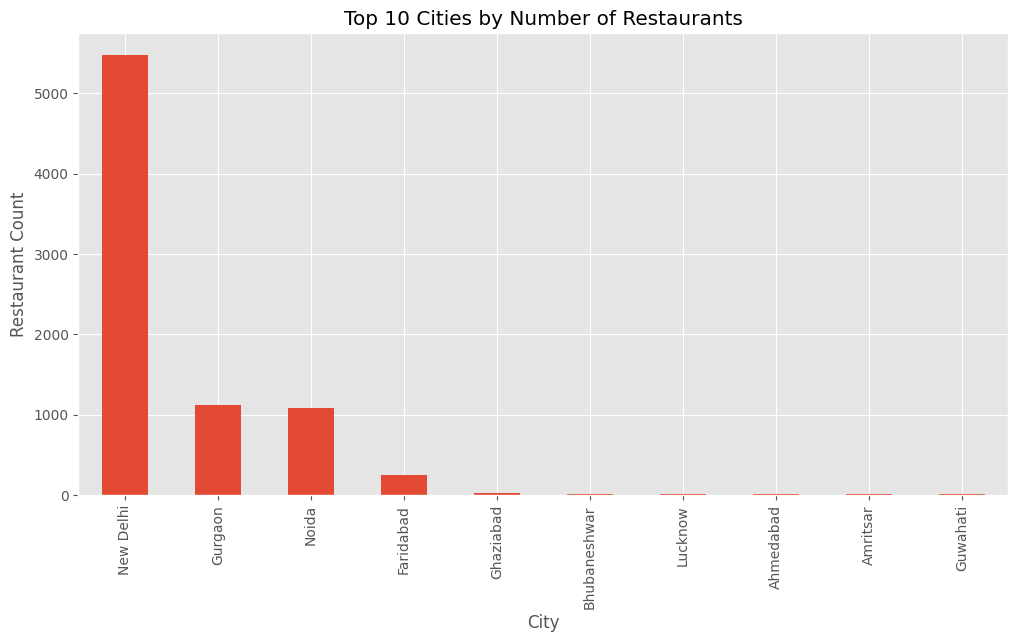

In [38]:
plt.figure(figsize=(12,6))

clean_df['City'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Restaurant Count')

plt.show()

## Line Chart

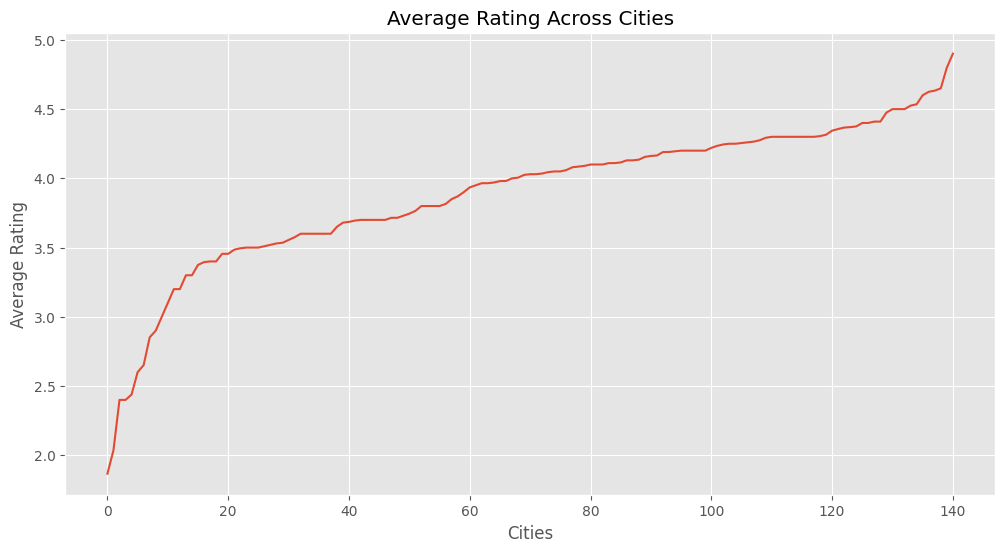

In [39]:
city_rating = clean_df.groupby('City')['Aggregate rating'].mean().sort_values()

plt.figure(figsize=(12,6))

plt.plot(city_rating.values)

plt.title('Average Rating Across Cities')
plt.xlabel('Cities')
plt.ylabel('Average Rating')

plt.show()

## Histogram

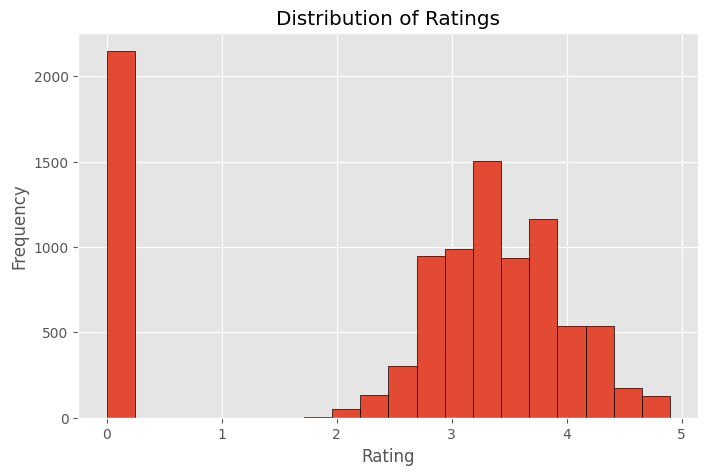

In [40]:
plt.figure(figsize=(8,5))

plt.hist(clean_df['Aggregate rating'], bins=20,edgecolor='black')

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

## Scatter Plot

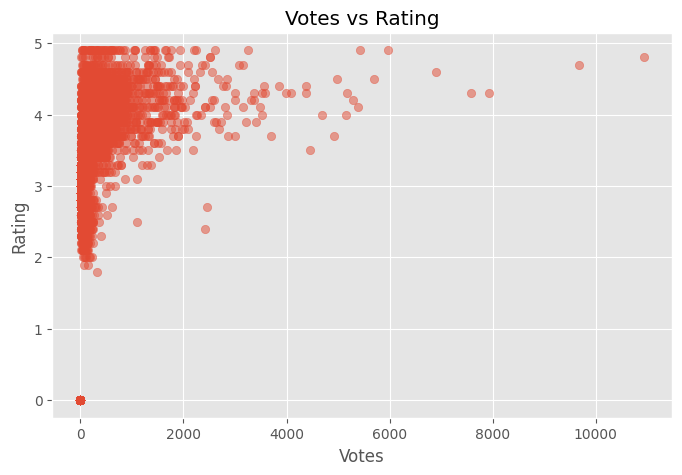

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    clean_df['Votes'],
    clean_df['Aggregate rating'],
    alpha=0.5
)

plt.title('Votes vs Rating')
plt.xlabel('Votes')
plt.ylabel('Rating')

plt.show()

## Pie Chart

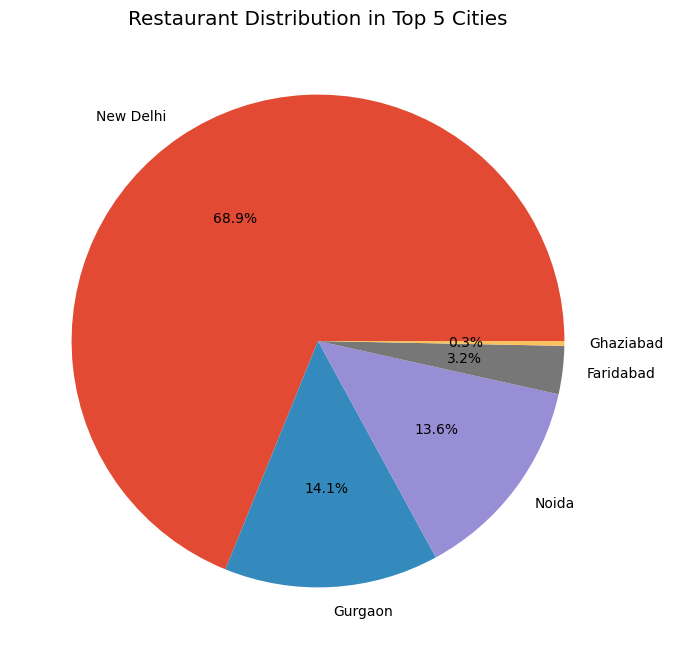

In [42]:
top_cities = clean_df['City'].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top_cities,
    labels=top_cities.index,
    autopct='%1.1f%%'
)

plt.title('Restaurant Distribution in Top 5 Cities')

plt.show()

## Heatmap

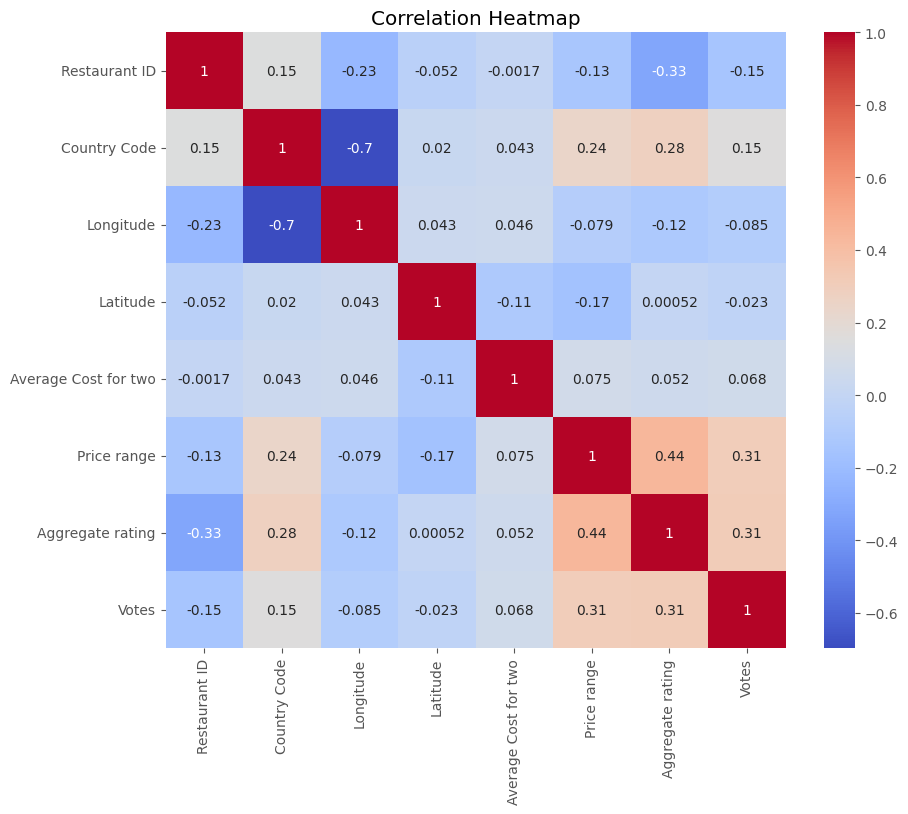

In [44]:
plt.figure(figsize=(10,8))

sns.heatmap(
    clean_df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# **STEP 5: INSIGHTS REPORT**

#Insight 1

New Delhi has the highest number of restaurants (5473), making it the largest restaurant market in the dataset.

#Insight 2

North Indian cuisine is the most popular cuisine with 936 restaurants, followed by North Indian-Chinese with 511 restaurants.

#Insight 3

Inner City has the highest average restaurant rating of 4.9, indicating high customer satisfaction.

#Insight 4

Jakarta has the highest average cost for two people (308437.5), showing large differences in restaurant pricing across cities.

#Insight 5

The correlation between Votes and Aggregate Rating is 0.314, indicating a weak positive relationship.

#Conclusion

This project analyzed the Zomato Restaurant dataset using Python, Pandas, Matplotlib, and Seaborn. After cleaning the data, exploratory analysis revealed that New Delhi has the highest number of restaurants, North Indian cuisine is the most common, and Inner City has the highest average restaurant ratings. The visualizations provided meaningful insights into restaurant distribution, pricing, customer ratings, and voting patterns. Overall, the analysis demonstrates how data analytics can help understand restaurant trends and customer preferences.